**CSI 4106 Introduction to Artificial Intelligence** <br/>
*Assignment 2: Machine Learning*

# Identification

Name: Kaitlyn Wong<br/>
Student Number: 300201087

Name: Sooriya Radhakrishnan<br/>
Student Number: 300175667

# 1. Exploratory Analysis

## Data Exploration

In this assignment, we will utilize the Diabetes Prediction Dataset, accessible via [Diabetes Prediction Dataset](https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset/data). To mitigate the complexity associated with Kaggle's login requirement, the dataset has been made available on a public GitHub repository:

- [github.com/turcotte/csi4106-f24/tree/main/assignments-data/a2](https://github.com/turcotte/csi4106-f24/tree/main/assignments-data/a2)

You can access and read the dataset directly from this GitHub repository in your Jupyter notebook.

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

1. **Load the dataset and provide a summary of its structure**:

    - Describe the features (columns), their data types, and the target variable.

In [2]:
# Code cell
diabetes_url = "https://raw.githubusercontent.com/turcotte/csi4106-f24/refs/heads/main/assignments-data/a2/diabetes_prediction_dataset.csv"

diabetes = pd.read_csv(diabetes_url)

print(diabetes.head())

   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  


In [3]:
# The features after looking at the top of the dataset are: 
# Gender - String
# Age - float
# hypertension - boolean
# heart_disease - boolean
# smoking_history - string
# bmi - float
# HbA1c_level - float
# blood_glucose_level - Integer 
# diabetes - Boolean (Class Label / target label)

2. **Feature Distribution Analysis**:

    - Examine the distribution of each feature using appropriate visualizations such as histograms and boxplots. Discuss insights gained, including the presence of outliers.

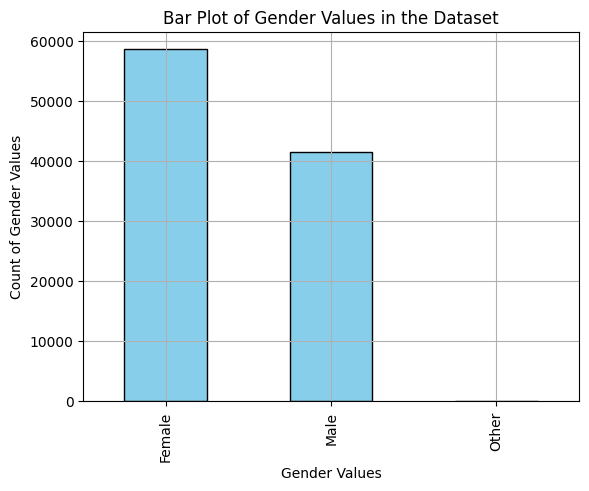

gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64


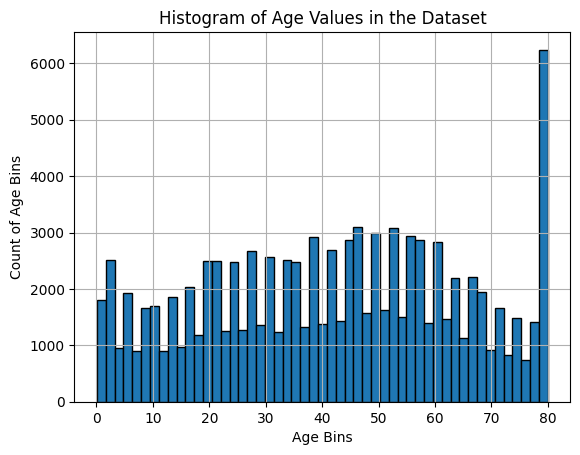

number of bins: 51


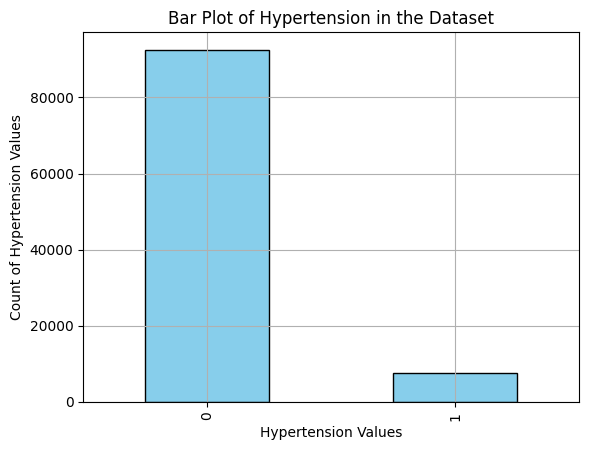

hypertension
0    92515
1     7485
Name: count, dtype: int64


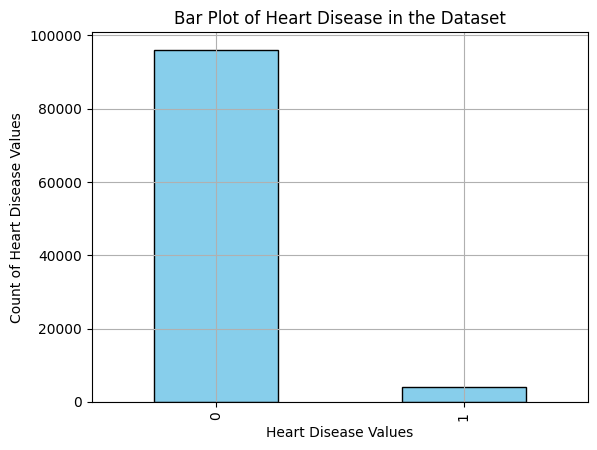

heart_disease
0    96058
1     3942
Name: count, dtype: int64


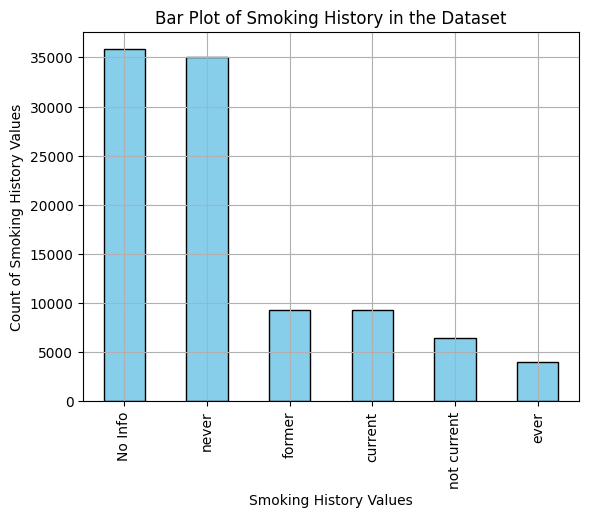

smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64


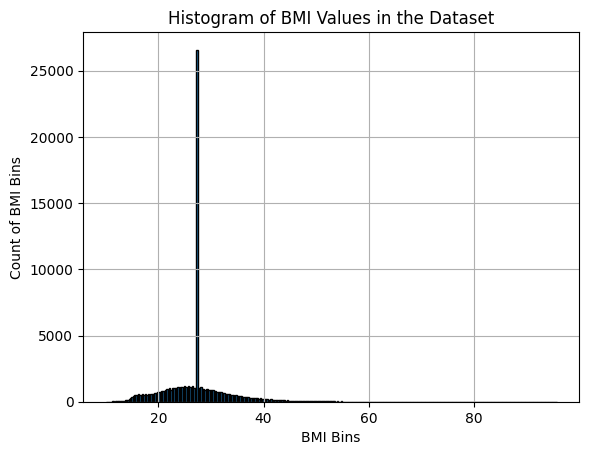

number of bins: 334


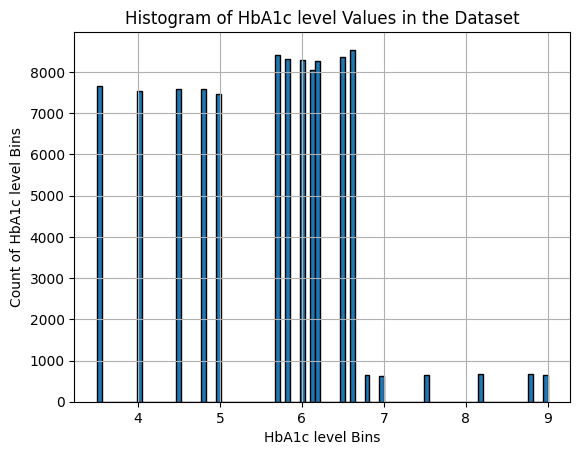

number of bins: 91


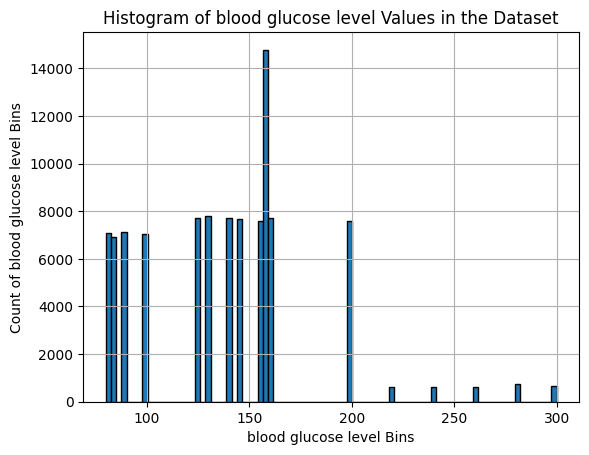

number of bins: 86


In [43]:
# Code cell
gender = diabetes["gender"]

# Create a bar plot to show counts of each category
gender.value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Bar Plot of Gender Values in the Dataset')
plt.xlabel('Gender Values')
plt.ylabel('Count of Gender Values')
plt.grid(True)
plt.show()
print(gender.value_counts())

def num_bins(column_name, df):
    c = df[column_name]
    q1 = np.percentile(c, 25)  
    q3 = np.percentile(c, 75)  
    iqr = q3 - q1
    bin_width = (2 * iqr) / (len(c) ** (1/3))
    num_bins = int((c.max() - c.min()) / bin_width)
    return num_bins

n_bin = num_bins("age", diabetes)
diabetes['age'].hist(bins=n_bin, edgecolor= 'black')
plt.title('Histogram of Age Values in the Dataset')
plt.xlabel('Age Bins')
plt.ylabel('Count of Age Bins')
plt.show()
print(f"number of bins: {n_bin}")

ht = diabetes["hypertension"] 
ht.value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Bar Plot of Hypertension in the Dataset')
plt.xlabel('Hypertension Values')
plt.ylabel('Count of Hypertension Values')
plt.grid(True)
plt.show()
print(ht.value_counts())

Heart = diabetes["heart_disease"]
Heart.value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Bar Plot of Heart Disease in the Dataset')
plt.xlabel('Heart Disease Values')
plt.ylabel('Count of Heart Disease Values')
plt.grid(True)
plt.show()
print(Heart.value_counts())

smoker = diabetes["smoking_history"]
smoker.value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Bar Plot of Smoking History in the Dataset')
plt.xlabel('Smoking History Values')
plt.ylabel('Count of Smoking History Values')
plt.grid(True)
plt.show()
print(smoker.value_counts())

n_bin = num_bins("bmi", diabetes)
diabetes['bmi'].hist(bins=n_bin, edgecolor= 'black')
plt.title('Histogram of BMI Values in the Dataset')
plt.xlabel('BMI Bins')
plt.ylabel('Count of BMI Bins')
plt.show()
print(f"number of bins: {n_bin}")

n_bin = num_bins("HbA1c_level", diabetes)
diabetes['HbA1c_level'].hist(bins=n_bin, edgecolor= 'black')
plt.title('Histogram of HbA1c level Values in the Dataset')
plt.xlabel('HbA1c level Bins')
plt.ylabel('Count of HbA1c level Bins')
plt.show()
print(f"number of bins: {n_bin}")


n_bin = num_bins("blood_glucose_level", diabetes)
diabetes['blood_glucose_level'].hist(bins=n_bin, edgecolor= 'black')
plt.title('Histogram of blood glucose level Values in the Dataset')
plt.xlabel('blood glucose level Bins')
plt.ylabel('Count of blood glucose level Bins')
plt.show()
print(f"number of bins: {n_bin}")


In [ ]:
# Gender:
# This feature after analyzing the bar plot (categorical), we can see that the data is close to balanced, there is an occurence of more females in the data set.
# The outlier is the other category which has only 18 entries in the data set. 

# Age: 
# This feature after analyzing the histogram (numerical), we can see that the data is left skewed, where most of the entries in the database are in the upper echelon 
# of the ages, according to the histogram no outliers are very present, however there is a large leap in entries that have an age attribute of 80 years old.

# Hypertension: 
# This feature is not balanced in the dataset, majority of the records do not have hpyertension, with no outliers in this category which we can see from the 
# bar plot 

# heart_disease: 
# This feature is also very imbalanced as majority of the entries did not have heart disease, with no actual outliers in this category. 

# smoking_history 
# This feature is considered imbalanced, most of the records either did not have any information about smoking history or did not smoke before.
# Not current and Former may be redudundant as the wording is ambigous but there are no outliers present in this feature.

# bmi 
# This feature is also very imbalanced as many of the records have a bmi in the range near the end of the 20s to the start of the 30s. This feature is right skewed, 
# which we can see in the histogram, BMI contains outliers which are not shown on the histogram due to the very small occurance of them.

# HbA1c_level
# This feature is very right skewed which we can see in the histogram. Outliers are present in this feature as well.  

# blood_glucose_level
# Thsi feature is also right skewed according to the histogram and also includes outliers in the dataset. 


3. **Target Variable Distribution**:

    - Analyze the distribution of the target variable to identify class imbalances. Use bar plots to visualize the class frequencies.

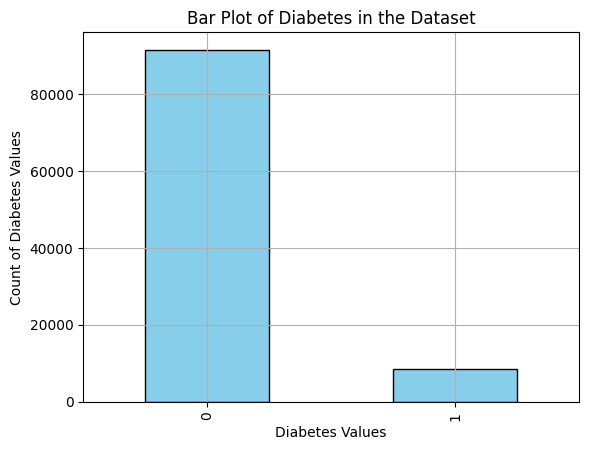

diabetes
0    91500
1     8500
Name: count, dtype: int64


In [45]:
# Code cell
target = diabetes['diabetes']
target.value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Bar Plot of Diabetes in the Dataset')
plt.xlabel('Diabetes Values')
plt.ylabel('Count of Diabetes Values')
plt.grid(True)
plt.show()
print(target.value_counts())

In [ ]:
# Diabetes (Target Label)
# We can see there is an imbalance in class labels with majority of the class labels being 0 which is no diabetes, there are no outliers present.

4. **Data Splitting**:

    - Split the dataset into training (80%) and test (20%) sets using the holdout method.

    - Ensure that this split occurs before any preprocessing to avoid data leakage.

In [50]:
# Code cell
X = diabetes.values[:, :-1]
y = diabetes.values[:,-1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
print('Training Set Size', X_train.shape, y_train.shape)
print('Testing Set Size', X_test.shape, y_test.shape)

Training Set Size (80000, 8) (80000,)
Testing Set Size (20000, 8) (20000,)


## Data Pre-Processing

5. **Categorical Variable Encoding**:

    - Encode any categorical variables. Justify the chosen method.

In [7]:
# Code cell

6. **Normalization/Standardization of Numerical Features**:

    - Normalize or standardize numerical features if necessary. Describe the technique used (e.g., Min-Max scaling, StandardScaler) and explain why it is suitable for this dataset.

    - Ensure that this technique is applied only to the training data, with the same transformation subsequently applied to the test data without fitting on it.

In [8]:
# Code cell

## Model Development & Evaluation

7. **Model Development**:

    - Implement the machine learning models covered in class: Decision Trees, K-Nearest Neighbors (KNN), and Logistic Regression. Use the default parameters of scikit-learn as a baseline for training each model.

In [9]:
# Code cell

8. **Model Evaluation**:

    - Use cross-validation to evaluate each model, justifying your choice of the number of folds.

    - Assess the models using metrics such as precision, recall, and F1-score.

In [10]:
# Code cell

## Hyperparameter Optimization

9. **Exploration and Performance Evaluation:**

    - Investigate the impact of varying hyperparameter values on the performance of each model.

    - Focus on the following relevant hyperparameters for each model:

        - [DecisionTreeClassifier](https://scikit-learn.org/dev/modules/generated/sklearn.tree.DecisionTreeClassifier.html): `criterion` and `max_depth`.
  
        - [LogisticRegression](https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LogisticRegression.html): `penalty`, `max_iter`, and `tol`.
  
        - [KNeighborsClassifier](https://scikit-learn.org/dev/modules/generated/sklearn.neighbors.KNeighborsClassifier.html): `n_neighbors` and `weights`.

    - Employ a grid search strategy or utilize scikit-learn's built-in methods to thoroughly evaluate all combinations of hyperparameter values. Cross-validation should be used to assess each combination.

    - Quantify the performance of each hyperparameter configuration using precision, recall, and F1-score as metrics.

    - Display the results in a tabular or graphical format (e.g., line charts, bar charts) to effectively demonstrate the influence of hyperparameter variations on model performance.

    - Specify the default values for each hyperparameter tested.

    - Analyze the findings and offer insights into which hyperparameter configurations achieved optimal performance for each model.

In [11]:
# Code cell

## Analysis of Results

10. **Model Comparison**:

    - Compare the results obtained from each model.

    - Discuss observed differences in model performance, providing potential explanations. Consider aspects such as model complexity, data imbalance, overfitting, and the impact of parameter tuning on overall results.

    - Provide recommendations on which model(s) to choose for this task and justify your choices based on the analysis results.

    - Train the recommended model(s) using the optimal parameter values identified from the parameter optimization step. Subsequently, apply the trained model to the test data. Document your observations comprehensively. Specifically, evaluate whether the results derived from cross-validation are consistent with those obtained from the test set.

In [12]:
# Code cell

## 2. Documentation of Exploratory Analysis

The report should comprehensively document the entire process followed during this assignment. The Jupyter Notebook must include the following:

- Your name(s), student number(s), and a report title.
- Explain how the tasks have been split between the members. How did you make sure that both students achieve the learning outcomes? 
- A section for each step of the exploratory analysis, containing the relevant Python code and explanations or results.
  - For sections requiring Python code, include the code in a cell.
  - For sections requiring explanations or results, include these in a separate cell or in combination with code cells.
- Ensure logical separation of code into different cells. For example, the definition of a function should be in one cell and its execution in another. Avoid placing too much code in a single cell to maintain clarity and readability.
- The notebook you submit must include the results of the execution, complete with graphics, ensuring that the teaching assistant can grade the notebook without needing to execute the code.

# Resources